# fastcdp

> Lightweight Chrome Debug Protocol (CDP) client for python

fastcdp provides an async Python client for the [Chrome DevTools Protocol](https://chromedevtools.github.io/devtools-protocol/) (CDP) over WebSocket. It auto-discovers Chrome's debug port, loads the full protocol schema from bundled JSON files, and exposes every CDP domain as a Python attribute with auto-generated signatures and docstrings — e.g. `await cdp.page.navigate(url=...)`.

It includes a `Page` class for tab-scoped operations, event subscription via `cdp.on()`/`cdp.wait_event()`, navigation helpers (`goto`, `wait_for_selector`, `wait_for`), screenshot capture, and accessibility tree access. A `cdp_search` utility lets you search CDP commands by name or description. For use inside [safepyrun](https://github.com/AnswerDotAI/safepyrun) sandboxes, `cdp_yolo()` registers all CDP classes.

## Installation

Install latest from [pypi][pypi]


```sh
$ pip install fastcdp
```

[pypi]: https://pypi.org/project/fastcdp/

## How to use

In [ ]:
from fastcdp import *

Chrome 146+ has built-in remote debugging support. Navigate to `chrome://inspect/#remote-debugging` and enable "Allow remote debugging for this browser instance":


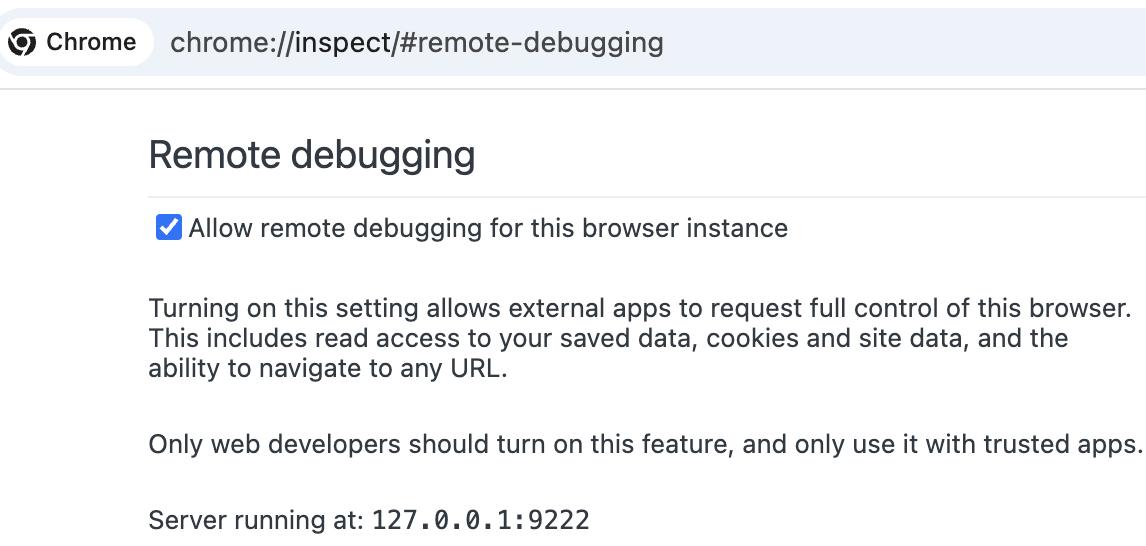


### The CDP class

Connect to Chrome (which will pop up a permissions window):

In [ ]:
cdp = await CDP.connect()

Every CDP domain is available as an attribute with auto-generated signatures. You can search for commands with `cdp_search`:

In [ ]:
cdp_search('screenshot')

"Emulation.setVisibleSize: Resizes the frame/viewport of the page. Note that this does not affect the frame's container\n(e.g. browser window). Can \nHeadlessExperimental.beginFrame: Sends a BeginFrame to the target and returns when the frame was completed. Optionally captures a\nscreenshot from the res\n  evt Overlay.screenshotRequested: Fired when user asks to capture screenshot of some area on the page.\nPage.captureScreenshot: Capture page screenshot."

List open pages and attach to one:

In [ ]:
ps = await cdp.pages
pg = ps[0]
pg['title']

'8. Database Transactions — PlanetScale'

In [ ]:
tid = pg['targetId']
sid = await cdp.attach(tid)
await cdp.eval('document.title', sid)

'8. Database Transactions — PlanetScale'

The `Page` class wraps a tab with its own session, so you don't need to pass `sid` everywhere:

In [ ]:
page = await cdp.new_page()
await page.goto('https://httpbin.org/forms/post')

You can `wait_for` any js expression to be truthy, and have it returned:

In [ ]:
await page.wait_for('document.title')

'6. httpbin.org/forms/post'

Take a screenshot of the page:

In [ ]:
img = await page.screenshot()

Clean up when done:

In [ ]:
await page.close()
await cdp.close()

See `CDP` docs for full details.

## Page.new and Filling forms

Instead of `CDP.connect`, you can call `Page.new` with no params to automatically create a CDP object and attach it to a new page:

In [ ]:
page = await Page.new()
await page.goto('https://httpbin.org/forms/post')

For finding elements to interact with, use `ax_tree`:

In [ ]:
root = await page.ax_tree()
print(str(root)[:300])

- **RootWebArea** "6. httpbin.org/forms/post" `focusable=True` `focused=True` `url=https://httpbin.org/forms/post` [#2]
  - **LabelText** "" [#24]
    - **StaticText** "Customer name: " [#64]
      - **InlineTextBox** "Customer name: "
    - **textbox** "Customer name: " `focusable=True` `editable=p


`find` and `find_id` are used to identify elements in the tree:

In [ ]:
nmid = root.find_id('textbox', 'Customer name')
nmid

4

You can use regular CDP methods, or one of the provided shortcuts:

In [ ]:
await page.fill_text(nmid, 'Jeremy Howard')
await page.click(root.find_id('radio', 'Large'))
await page.js_node_run('this.value = "18:30"', root.find_id('InputTime', 'delivery time'))

{'type': 'undefined'}

You can use `click` to click a button, or `click_and_wait` to wait for the next page to load:

In [ ]:
await page.click_and_wait(root.find_id('button', 'Submit order'))

When using `page.New()`, `close()` also shuts down the CDP websocket.

In [ ]:
await page.close()

To allow LLMs like solveit with safepyrun to access fastcdp, use:

```python
cdp_yolo()
```

Then open a controlled page for it:

```python
page = await Page.new()
```

Then use a prompt such as:

> Try using pyrun to go to `<url>` using the existing `page`, fill it out, read it to check it's filled correctly, then submit it, and see what you get back. Don't use find_id - you can get all the ids at once with ax_tree (don't truncate the result of it). Don't add extra waits etc - fastcdp handles it automatically. IDs can change so be sure to use the ax_tree IDs you read.